# Setup


📝 *Import required libraries and files:*

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import copy
# Text cleaning & preprocessing
import re
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
# Dimensionality reduction
from umap import UMAP
from hdbscan import HDBSCAN
# Topic modeling
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer


In [2]:
df = pd.read_parquet("../assets/intermediate_dfs/df_sentiment.parquet") 

# 4.2. - BERTopic modelling

### 4.2.1. - Prepare df for model training

In [3]:
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))
df['word_count'].describe().round(1)

count    653426.0
mean         12.2
std          17.4
min           1.0
25%           2.0
50%           6.0
75%          14.0
max         552.0
Name: word_count, dtype: float64

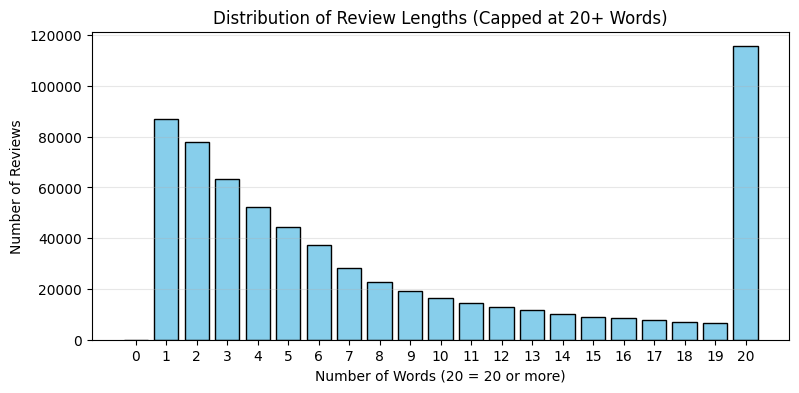

In [4]:
# Calculate number of words per review
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))

# Cap word counts at 20
df['word_count_capped'] = df['word_count'].apply(lambda x: x if x < 20 else 20)

# Count how many reviews per word count
counts = df['word_count_capped'].value_counts().sort_index()

# Ensure we have bins from 0 to 20 (fill missing ones with 0)
counts = counts.reindex(np.arange(0, 21), fill_value=0)

# Plot
plt.figure(figsize=(9, 4))
plt.bar(counts.index, counts.values, color='skyblue', edgecolor='black')
plt.title("Distribution of Review Lengths (Capped at 20+ Words)")
plt.xlabel("Number of Words (20 = 20 or more)")
plt.ylabel("Number of Reviews")
plt.xticks(range(0, 21))
plt.grid(axis='y', alpha=0.3)
plt.show()

In [5]:
print(f"Total reviews: {len(df)}")

# Create a subset of the dataframe with reviews that have at least 4 words and are after October 1, 2021
df_sub1 = df[
    (df['review_text'].str.split().str.len() >= 4) &
    (df['review_date'] > pd.Timestamp('2021-10-01'))
].drop_duplicates(subset=['review_text'], keep='first').copy()

print(f"Total reviews of df_sub1 after filtering: {len(df_sub1)}")

# Create a subset of the dataframe with reviews that have at least 4 words and are before October 1, 2021
df_sub2 = df[
    (df['review_text'].str.split().str.len() >= 4) &
    (df['review_date'] <= pd.Timestamp('2021-10-01'))
].drop_duplicates(subset=['review_text'], keep='first').copy()

print(f"Total reviews of df_sub2 after filtering: {len(df_sub2)}")

Total reviews: 653426
Total reviews of df_sub1 after filtering: 212971
Total reviews of df_sub2 after filtering: 174448


In [6]:
# Setting basic stop words to favor topics related to functionality issues
PRAISE_WORDS = [
    "amazing", "awesome", "brilliant", "excellent", "fantastic", "love", "nice", "perfect", "star", "stars",
    "awful", "bad", "disappointing", "horrible", "poor", "terrible", "useless", "worst", "best"
]

CUSTOM_STOP_WORDS = [
    "santander", "revolut", "revolute", "revoult", "revlout", "revelout", "hsbc", "barclays", 
    "barclay", "lloyds","lloyd", "monzo", "app", "banking", "bank"
]

STOP_WORDS = PRAISE_WORDS + CUSTOM_STOP_WORDS

# BERTopic basic cleaning function
def bertopic_cleaning(df: pd.DataFrame, col: str = "review_text", name="df"):
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in DataFrame.")
    
    df[col] = df[col].apply(lambda x: re.sub(r"http\S+", "", str(x))) # Remove URLs
    df[col] = df[col].apply(lambda x: re.sub(r"\s+", " ", x).strip()) # Normalize spaces
    
    for w in STOP_WORDS:
        df[col] = df[col].apply(lambda x: re.sub(rf"\b{re.escape(w)}\b", "", x, flags=re.IGNORECASE)) # Remove stop words

    df[col] = df[col].apply(lambda x: re.sub(r"\s+", " ", x).strip()) # Normalize spaces again after stop word removal

    # elimnate rows with less than 2 words after cleaning
    df = df[df[col].str.split().str.len() >= 2].copy()

    # print number of rows after cleaning
    print(f"Number of reviews of {name} after cleaning: {len(df)}")

    return df

In [7]:
# Perform cleaning on both df_sub1 (recent reviews that will be used for training) and df_sub2 (for later inference)
df_sub1 = bertopic_cleaning(df_sub1, col="review_text", name="df_sub1")
df_sub2 = bertopic_cleaning(df_sub2, col="review_text", name="df_sub2")

Number of reviews of df_sub1 after cleaning: 212700
Number of reviews of df_sub2 after cleaning: 174210


In [8]:
# Pre-calculate embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings_sub1 = embedding_model.encode(df_sub1["review_text"].to_list(), show_progress_bar=True)
embeddings_sub2 = embedding_model.encode(df_sub2["review_text"].to_list(), show_progress_bar=True)

Batches:   0%|          | 0/6647 [00:00<?, ?it/s]

Batches:   0%|          | 0/5445 [00:00<?, ?it/s]

In [9]:
# Create directory one level up from the notebook folder
os.makedirs("../assets/models/bertopic", exist_ok=True)

# Save the files
np.save("../assets/models/bertopic/embeddings_sub1_miniLM_L6.npy", embeddings_sub1)
np.save("../assets/models/bertopic/embeddings_sub2_miniLM_L6.npy", embeddings_sub2)

## 4.2.2. - Unseeded topic modelling

### 4.2.2.1. - Model Training

In [13]:
# Load embeddings
embeddings_sub1 = np.load("../assets/models/bertopic/embeddings_sub1_miniLM_L6.npy")

In [14]:
# Dimensionality reduction tuned for short reviews
umap_model = UMAP(
    n_neighbors=30,           # lower values (5-10) --> more, smaller and tighter clusters; higher values (50-100) --> fewer, larger clusters
    n_components=5,           # number of dimensions to reduce embeddings before clustering. For app reviews 5 tends to be standard
    min_dist=0.0,             # controls how tight we want the clustering to be. 0.0 is recommended for BERTopic --> HDBSCAN works better with tightly packed clusters
    metric="cosine",          # cosine distance is best for text embeddings
    random_state=42)          # ensure reproducibility

# Clustering tuned for short reviews
hdbscan_model = HDBSCAN(
    min_cluster_size=150,      # minimum number of documents required to form a cluster
    cluster_selection_epsilon=0.3,    # Merge clusters within 0.3 distance
    min_samples=None,         # if None, min_samples = min_cluster_size
    metric="euclidean",       # recomended for BERTopic
    cluster_selection_method="eom", 
    prediction_data=True)

# Vectorizer 
STOP_WORDS = PRAISE_WORDS + CUSTOM_STOP_WORDS + list(ENGLISH_STOP_WORDS)
vectorizer_model = CountVectorizer(
    stop_words= STOP_WORDS,
    ngram_range=(1, 2),       # unigrams and bigrams  
    min_df=10,                 # ignores terms appearing in less than 'n' documents
    max_df=0.5                # ignores terms appearing in more than 'x%' of documents
)

# Create the BERTopic model
unseed_topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="english",             
    calculate_probabilities=True,   
    verbose=True)

In [15]:
topics, probs = unseed_topic_model.fit_transform(df_sub1["review_text"].to_list(), embeddings_sub1)

2025-10-23 18:56:35,233 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-23 19:03:30,627 - BERTopic - Dimensionality - Completed ✓
2025-10-23 19:03:30,643 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-23 19:11:37,884 - BERTopic - Cluster - Completed ✓
2025-10-23 19:11:37,938 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-23 19:11:42,403 - BERTopic - Representation - Completed ✓


In [16]:
# Save Bertopic model 
unseed_topic_model.save("../assets/models/bertopic/unseed_model")

2025-10-23 19:11:43,528 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


### 4.2.2.2. - Model evaluation and finetune

In [17]:
unseed_topic_model = BERTopic.load("../assets/models/bertopic/unseed_model")

In [18]:
unseed_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,34135,-1_accounts_credit_payments_transactions,"[accounts, credit, payments, transactions, pay...",[had a recent design update which is to look a...
1,0,77237,0_log_payments_accounts_payment,"[log, payments, accounts, payment, crypto, exc...",[I think I will close the account soon. When I...
2,1,21334,1_use works_use does_use helpful_use useful,"[use works, use does, use helpful, use useful,...","[Easy to use and very helpful !, Easy to use. ..."
3,2,8779,2_secure easy_use secure_reliable easy_safe easy,"[secure easy, use secure, reliable easy, safe ...","[Very secure and easy to use., Efficient, secu..."
4,3,8527,3_good service_great service_service easy_serv...,"[good service, great service, service easy, se...","[Very very good service, and easy service, Goo..."
...,...,...,...,...,...
62,61,174,61_options easy_use options_lots options_optio...,"[options easy, use options, lots options, opti...","[Great options very easy to use, many options,..."
63,62,171,62_class_1st class_1st_described,"[class, 1st class, 1st, described, usual, life...","[first class; highly satisfied., Always found ..."
64,63,162,63_use functional_functional easy_functionalit...,"[use functional, functional easy, functionalit...","[Easy to use and functional, Very easy to use ..."
65,64,161,64_2025_2024_2022_2023,"[2025, 2024, 2022, 2023, 2020, 2021, july, jun...","[absolutely update may 2025, A very good . Not..."


In [19]:
# create a new vectorizer with English stop words
GENERAL_WORDS = ["app", "bank", "banking", "great","use","very","easy","extremelly", "get","like","love","good","time","work",
                 "well","new","best","nice","better", "one","make","also","see","want","need","always","much",
                 "still","way","even","look","really","thank","thanks", 'able', 'absolutely', 'accounts', 'add', 'ago', 'alot', 
                 'allows', 'amazing', 'anymore', 'appropriate','awesome', 'bad', 'banking', 'best', 'better', 'bit', 'branch', 
                 'brilliant', 'business', 'change', 'cheque', 'cheques','clear', 'close', 'complicated', 
                 'convenient', 'constantly', 'daily', 'date', 'day', 'days', 'definitely', 'did', 'didnt', 'different', 'difficult', 'does', 
                 'doesnt', 'doing', 'dont', 'ease', 'easier', 'easily', 'easy', 'effective', 'efficient', 'especially', 'exactly', 'excellent', 
                 'experience', 'extremely', 'fab', 'fantastic', 'far', 'fast', 'feels','finances', 'fine', 'fix', 'follow', 'forward', 'getting', 
                 'gives', 'going', 'good', 'google', 'got', 'great', 'guys', 'handy', 'happy', 'havent', 'having', 'hassle', 'hello', 'helpful', 
                 'helps', 'highly', 'hope', 'hoping', 'improved', 'isnt', 'issues', 'job', 'just','keeping', 'keeps', 'know', 'latest', 'let', 
                 'lets', 'life', 'like', 'little', 'live', 'long', 'longer', 'lot', 'lots', 'love', 'loving','make', 'makes', 'making', 'month', 
                 'months', 'need', 'needed', 'needs', 'neo', 'new', 'nice', 'number', 'old', 'online','open', 'overall', 'payees', 'pending', 
                 'people', 'perfect', 'perfectly', 'place', 'pleased', 'poor', 'pretty', 'quick', 'quickly', 'quite', 'really', 'reason', 
                 'recommend', 'recommended', 'reliable', 'rooted', 'round', 'rubbish', 'safe', 'satisfied', 'saves', 'say', 'says', 'set', 
                 'simple', 'simpler', 'simply', 'slow', 'smooth', 'sort', 'star', 'stars', 'stopped', 'straighforward', 'straight', 
                 'straightforward', 'stuff', 'super', 'superb', 'sure', 'takes', 'team', 'terrible', 'thank', 'thats', 'think', 'thing', 
                 'things', 'time', 'times', 'tin', 'tried', 'try', 'trying', 'unable', 'understand', 'use', 'used', 'useful', 'useless', 
                 'using', 'usually', 'want', 'way', 'website', 'went', 'whats', 'wish', 'wonderful', 'wont', 'work', 'worked', 'working', 'works', 
                 'worst', 'wrong', 'years']
NEW_STOP_WORDS = STOP_WORDS + GENERAL_WORDS

new_vectorizer = CountVectorizer(stop_words= NEW_STOP_WORDS , min_df=2, ngram_range=(1, 2))

# update BERTopic’s internal vectorizer
unseed_topic_model.update_topics(
    df_sub1["review_text"].to_list(),                     
    vectorizer_model=new_vectorizer,
    representation_model=None   
)

In [20]:
unseed_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,34135,-1_account_money_phone_im,"[account, money, phone, im, ive, apps, credit,...",[had a recent design update which is to look a...
1,0,77237,0_account_money_update_log,"[account, money, update, log, transfer, phone,...",[I think I will close the account soon. When I...
2,1,21334,1_problems_problem_ive_problems problems,"[problems, problem, ive, problems problems, co...","[Easy to use and very helpful !, Easy to use. ..."
3,2,8779,2_secure_security_secure secure_secure security,"[secure, security, secure secure, secure secur...","[Very secure and easy to use., Efficient, secu..."
4,3,8527,3_service_service service_customer_services,"[service, service service, customer, services,...","[Very very good service, and easy service, Goo..."
...,...,...,...,...,...
62,61,174,61_options_options options_options available_a...,"[options, options options, options available, ...","[Great options very easy to use, many options,..."
63,62,171,62_class_class class_1st class_1st,"[class, class class, 1st class, 1st, classy, c...","[first class; highly satisfied., Always found ..."
64,63,162,63_functional_functional functional_functional...,"[functional, functional functional, functional...","[Easy to use and functional, Very easy to use ..."
65,64,161,64_2025_2024_2022_2023,"[2025, 2024, 2022, 2023, 2020, 2021, october, ...","[absolutely update may 2025, A very good . Not..."


In [21]:
# Visualize topics as a hierarchical tree
fig = unseed_topic_model.visualize_hierarchy()
fig.show()

In [22]:
# keep original untouched
unseed_try = copy.deepcopy(unseed_topic_model)

In [23]:
# reduce the number of topics
unseed_try.reduce_topics(df_sub1["review_text"].to_list(), nr_topics=25)

2025-10-23 19:18:18,434 - BERTopic - Topic reduction - Reducing number of topics
2025-10-23 19:18:18,551 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-23 19:18:21,337 - BERTopic - Representation - Completed ✓
2025-10-23 19:18:21,354 - BERTopic - Topic reduction - Reduced number of topics from 67 to 25


Manual exploration and topic merge

In [24]:
unseed_try.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,34135,-1_account_money_phone_im,"[account, money, phone, im, ive, apps, access,...",[I use it every day and find it very user frie...
1,0,90402,0_account_money_card_update,"[account, money, card, update, phone, transfer...","[The account 👌, Not able to get to .my account..."
2,1,63146,1_service_secure_navigate_friendly,"[service, secure, navigate, friendly, problems...","[Great Service Thank You., I'm happy with your..."
3,2,9971,2_im_ok_lovely_enjoying,"[im, ok, lovely, enjoying, cool, ive, moment, ...","[It's ok got to get used to it, all ok. easy e..."
4,3,3249,3_paying_pay_deposit_photo,"[paying, pay, deposit, photo, picture, camera,...","[Really easy to use , it has got better over t..."
5,4,2307,4_chat_statements_support_download,"[chat, statements, support, download, messages...","[Chat was on, Can't get onto chat, I want to h..."
6,5,1614,5_concise_information_friendly_clearer,"[concise, information, friendly, clearer, user...","[Ease of use. Clear and concise., clear concis..."
7,6,1336,6_la_que_si_en,"[la, que, si, en, para, el, es, et, se, nu]",[Es el medio de pago con el que menos sorpresa...
8,7,1003,7_review_rating_rate_asking,"[review, rating, rate, asking, reviews, asking...",[great. I give 5 and I like . if something hap...
9,8,988,8_branches_local_closed_visit,"[branches, local, closed, visit, closing, staf...","[Great. We need more branches., I wouldn't be ..."


In [25]:
# Visualize topics as a hierarchical tree
fig = unseed_try.visualize_hierarchy()
fig.show()

In [26]:
unseed_try.visualize_barchart(width = 280, height = 330, top_n_topics=15, n_words=10)

In [27]:
# further analysis on dominant topic
dominant_topic = 0 
big_topic_docs = [df_sub1["review_text"].to_list()[i] for i, t in enumerate(topics) if t == dominant_topic]

In [28]:
big_topic_embs = np.array([embeddings_sub1[i] for i, t in enumerate(topics) if t == dominant_topic])

In [29]:
# Smaller, more local neighborhood = finer clusters
umap_model = UMAP(
    n_neighbors=15,       # fewer neighbors → more detailed clusters
    n_components=10,      # 5–15 usually works well
    min_dist=0.0,
    metric="cosine"
)

# Allow smaller topic sizes than before
hdbscan_model = HDBSCAN(
    min_cluster_size=1000, 
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

subtopic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    calculate_probabilities=True,
    verbose=True
)

In [30]:
sub_topics, sub_probs = subtopic_model.fit_transform(big_topic_docs, big_topic_embs)

2025-10-23 19:27:33,652 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-23 19:30:29,554 - BERTopic - Dimensionality - Completed ✓
2025-10-23 19:30:29,569 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-23 19:30:55,548 - BERTopic - Cluster - Completed ✓
2025-10-23 19:30:55,553 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-23 19:30:56,326 - BERTopic - Representation - Completed ✓


In [31]:
subtopic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2030,-1_the_to_and_is,"[the, to, and, is, rooted, my, not, it, on, re...","[No. Simply say ""No"". One day after some rando..."
1,0,29565,0_the_to_it_and,"[the, to, it, and, my, is, not, on, update, in]","[I do like the , it's normally user friendly. ..."
2,1,27299,1_to_and_the_money,"[to, and, the, money, my, for, it, easy, you, is]",[I have written to the so many times about the...
3,2,9025,2_for_and_exchange_to,"[for, and, exchange, to, great, currency, abro...","[Easy to use and great exchange rates, , great..."
4,3,3320,3_account_accounts_easy_to,"[account, accounts, easy, to, and, use, my, ve...","[Easy to open account and easy to use, Easy to..."
5,4,2859,4_crypto_and_for_to,"[crypto, and, for, to, the, is, stocks, tradin...","[With you can buy stocks and crypto, Very good..."
6,5,1579,5_notifications_the_notification_to,"[notifications, the, notification, to, and, pu...",[All my notifications are on in both and devic...
7,6,1560,6_balance_the_widget_to,"[balance, the, widget, to, is, it, and, quick,...",[Well the Quick Glance widget is back at long ...


As it can be seen, the unseeded model is showing a propensity to create a big cluster of reviews. Even after trying to create a subtopic_model on top of the dominant topic, we still obtain a large subtopic that absorbs the majority of the reviews of the dominant topic. We could do some additional finetune of the training to 'force' the creation of smaller clusters. However, since we already know which type of issues/topics are we dealing with, we will try a different modelling approach using a seeded list and check if we get better results.

## 4.2.3. -  Seeded Topic Modeling

#### 4.2.3.1. - Model Training

In [32]:
seed_topic_list = [
    ["service", "customer service", "support", "customer support", "chat", "help", "problem", "contact", "assistance", "agent", "answer"], # customer support
    ["safe", "unsafe", "safety", "fingerprint", "authentication", "auth", "reliable"], # security & authentication
    ["login", "access", "fingerprint", "password", "pass", "log", "sign in", "locked", "access denied", "session"], # login
    ["payments", "pay", "transactions", "transfers", "send money"], # payments & transfers
    ["quick", "slow", "performance", "crashes", "bug", "speed", "error", "lag", "freeze", "responsive"], # performance
    ["pretty", "layout", "navigation", "interface", "design", "menu", "scroll"], # navigation & layout
    ["simple", "easy to use", "complex", "convenient", "experience", "intuitive", "complicated"], # simplicity
    ["price", "free", "rates", "cheap", "expensive", "cost"], # price
    ["card", "card lost", "credit card", "debit", "contactless"], # cards
    ["feature", "investments", "crypto", "cashback", "option", "settings", "preferences"], # features
    ["manage", "balance", "money management", "track", "expenses", "bills", "control", "budget", "direct debits", "spending"], # money management
    ["exchange", "foreign", "rates", "abroad", "currency", "travel", "forex"], # travelling
    ["update", "version", "previous", "old", "android", "phone", "ios", "device"], # updates
    ["notifications", "notification", "alerts"], # notifications
    ["cheques", "scan", "deposits"], # cheque deposits
    ["good", "so far so good", "best app"] # general praise
]

In [33]:
# UMAP - more granular for better separation
umap_model = UMAP(
    n_neighbors=30,
    n_components=5,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

# HDBSCAN - smaller clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=150,
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# Vectorizer - customize to your needs
vectorizer_model = CountVectorizer(
    stop_words = STOP_WORDS,
    ngram_range=(1, 2),         # unigrams + bigrams
    min_df=10,                  # ignore extremely rare words
    max_df=0.5,                 # ignore overly frequent words
)

# Initialize BERTopic with seed topics
seed_topic_model = BERTopic(
    embedding_model=None,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    seed_topic_list=seed_topic_list,
    verbose=True,
    calculate_probabilities=True  # Useful for later refinement
)

In [34]:
# Fit Model
topics, probs = seed_topic_model.fit_transform(df_sub1["review_text"].to_list(), embeddings_sub1)

2025-10-23 19:43:19,826 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-23 19:52:41,215 - BERTopic - Dimensionality - Completed ✓
2025-10-23 19:52:41,215 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-23 19:59:47,492 - BERTopic - Cluster - Completed ✓
2025-10-23 19:59:47,541 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-23 19:59:52,268 - BERTopic - Representation - Completed ✓


In [35]:
# Save Bertopic model 
seed_topic_model.save("../assets/models/bertopic/seed_model")

2025-10-23 19:59:54,424 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


### 4.2.3.2. - Model evaluation and finetune

In [36]:
seed_topic_model = BERTopic.load("../assets/models/bertopic/seed_model")

In [37]:
# Check the results
seed_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,86033,-1_payments_log_transfer_transfers,"[payments, log, transfer, transfers, accounts,...","[The way the operates changes too frequently, ..."
1,0,7001,0_card_cards_virtual_debit,"[card, cards, virtual, debit, credit card, use...","[and card, card and !, It is really good card]"
2,1,3976,1_easy easy_makes life_life easier_easy quick,"[easy easy, makes life, life easier, easy quic...","[. Makes life so much easier, Makes life easie..."
3,2,3667,2_finances_spending_track_control,"[finances, spending, track, control, manage mo...",[Never use the any more! Easy to keep up with ...
4,3,3178,3_accounts_account easy_accounts easy_manage a...,"[accounts, account easy, accounts easy, manage...","[accounts service, Very convenient, accounts a..."
...,...,...,...,...,...
187,186,152,186_transfer_transfers_money transfer_hours,"[transfer, transfers, money transfer, hours, p...","[To long at times when i transfer founds , ann..."
188,187,151,187_savings_rates_rate_savings account,"[savings, rates, rate, savings account, good r...",[It's quite ok but I wish I could get some int...
189,188,151,188_early_day early_paid early_paid,"[early, day early, paid early, paid, earlier, ...",[my and how I can get paid a day early and it'...
190,189,150,189_otp_sms_number_receive,"[otp, sms, number, receive, code, received, ph...","[Never get the otp code to login, It can't eve..."


In [38]:
# keep original untouched
seed_try = copy.deepcopy(seed_topic_model)

# Save topics before reduction
topics_before_reduction = np.array(topics)  

In [40]:
# Reduce topics - modifies the model and returns it
seed_try = seed_try.reduce_topics(df_sub1["review_text"].to_list(), nr_topics=101)

2025-10-23 20:02:25,421 - BERTopic - Topic reduction - Reducing number of topics
2025-10-23 20:02:25,507 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-23 20:02:28,840 - BERTopic - Representation - Completed ✓
2025-10-23 20:02:28,855 - BERTopic - Topic reduction - Reduced number of topics from 192 to 101


In [41]:
# Check the results
# pd.set_option("display.max_rows", None)   # enable to show all rows
seed_try.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,86033,-1_payments_log_transfers_payment,"[payments, log, transfers, payment, login, bil...","[Great for international travel and transfers,..."
1,0,11884,0_convenient easy_efficient easy_use convenien...,"[convenient easy, efficient easy, use convenie...","[convenient and easy to use, So useful, easy t..."
2,1,7309,1_cards_virtual_debit_credit card,"[cards, virtual, debit, credit card, barclayca...",[is one of the cards. Fraud is stopped immedia...
3,2,7291,2_finances_track_transaction_payments,"[finances, track, transaction, payments, finan...","[keeps me on top of my finances., Easy to use,..."
4,3,5987,3_exchange_currency_rates_currencies,"[exchange, currency, rates, currencies, transf...","[, , so handy when you are abroad, you get the..."
...,...,...,...,...,...
96,95,161,95_2025_2024_2022_2023,"[2025, 2024, 2022, 2023, 2020, march, june, 20...",[A very good . Not been disappointed to date. ...
97,96,151,96_savings_rates_savings account_good rates,"[savings, rates, savings account, good rates, ...",[It's quite ok but I wish I could get some int...
98,97,151,97_early_day early_paid_paid early,"[early, day early, paid, paid early, earlier, ...","[Convenient plus I get paid a day early! :-), ..."
99,98,150,98_otp_sms_receive_code,"[otp, sms, receive, code, received, phone numb...","[can't log in anymore OTP isn't working, OTP i..."


In [42]:
# Visualize topics as a hierarchical tree
fig = seed_try.visualize_hierarchy()
fig.show()

In [43]:
# INSPECT TOPIC DETAILS

df = seed_try.get_document_info(df_sub1["review_text"].to_list())
topic_id = 25

# Count number of documents for the topic
topic_count = df[df["Topic"] == topic_id].shape[0]
print(f"Number of documents in topic {topic_id}: {topic_count}\n")

# Get the words for the topic
topic_words = seed_try.get_topic(topic_id)
print(f"Top words for topic {topic_id}:\n")

for word, weight in topic_words:
    print(f"{word}: {weight:.4f}")
    
print ("\nTop documents for this topic:\n")

# Filter by topic and sort by probability
topic_docs = (
    df[df["Topic"] == topic_id]
    .sort_values("Probability", ascending=False)
    .head(10)["Document"]
    .tolist()
)

for i, doc in enumerate(topic_docs, 1):
    print(f"{i}. {doc}")

Number of documents in topic 25: 1438

Top words for topic 25:

need does: 0.4662
does want: 0.2196
need need: 0.1810
great does: 0.1748
need great: 0.1631
good does: 0.0996
does exactly: 0.0986
exactly need: 0.0820
need good: 0.0811
great need: 0.0718

Top documents for this topic:

1. Does everything I need
2. does what I need it to do
3. Does everything I need it to.
4. Does exactly what is needed thank you 😊
5. yeah does exactly what you need it to
6. Able to do all the things I need to.
7. does wat I need it to do.
8. I can do any thing that I need, till now
9. does everything I need it to do. Nowt wrong here.
10. be to see and do more things like the web


In [44]:
# count the number of documents for selected topics merge

print("\nMONEY MGMT AND TRAVEL-related topics breakdown:")
# money management
money_mgmt_topic_ids = [2,13,64,77,79]
money_mgmt_count = df[df["Topic"].isin(money_mgmt_topic_ids)].shape[0]
print(f"- Money management: {money_mgmt_count}")
# travel and forex
travel_topic_ids = [3,15,45,86]
travel_count = df[df["Topic"].isin(travel_topic_ids)].shape[0]
print(f"- Travel and forex: {travel_count}")

print("\nUSER EXPERIENCE-related topics breakdown:")
# UX_simplicity
simplicity_topic_ids = [0,4,32,47,55,80,81,99]
simplicity_count = df[df["Topic"].isin(simplicity_topic_ids)].shape[0]
print(f"- Simplicity: {simplicity_count}")
# UX_usability & interaction (navigation, overall experience, notifications and accessability)
ux_topic_ids = [7,31,53,56,88]
ux_count = df[df["Topic"].isin(ux_topic_ids)].shape[0]
print(f"- Usability & interaction: {ux_count}")
# UX_interface, features and layout
interface_topic_ids = [11,51,68]
interface_count = df[df["Topic"].isin(interface_topic_ids)].shape[0]
print(f"- Interface, features and layout: {interface_count}")
# UX_notifications
notifications_topic_ids = [29,63]
notifications_count = df[df["Topic"].isin(notifications_topic_ids)].shape[0]
print(f"- Notifications: {notifications_count}")

print("\nPERFORMANCE-related topics breakdown:")
# PERFORMANCE_stability - always works / available
stability_topic_ids = [19,28,33,39,49,73,74,90,92,94]
stability_count = df[df["Topic"].isin(stability_topic_ids)].shape[0]
print(f"- Stability ('always work/available'): {stability_count}")
# PERFORMANCE_updates
updates_topic_ids = [17,23,30]
updates_count = df[df["Topic"].isin(updates_topic_ids)].shape[0]
print(f"- Updates: {updates_count}")
# PERFORMANCE_compatability & launch issues
compatability_topic_ids = [18,36,37,67]
compatability_count = df[df["Topic"].isin(compatability_topic_ids)].shape[0]   
print(f"- Compatability and launch issues: {compatability_count}")
# PERFORMANCE_reliability - does what is expected
reliability_topic_ids = [9,25,71,72,76,85]
reliability_count = df[df["Topic"].isin(reliability_topic_ids)].shape[0]
print(f"- Reliability ('does what is expected'): {reliability_count}")
# PERFORMANCE_bugs with specific issues
bugs_topic_ids = [50,59,65,83,89]
bugs_count = df[df["Topic"].isin(bugs_topic_ids)].shape[0]
print(f"- Functional Bugs: {bugs_count}")

print("\nPRODUCT-related topics breakdown:")
# PRODUCT_cards
cards_topic_ids = [1]
cards_count = df[df["Topic"].isin(cards_topic_ids)].shape[0]
print(f"- Cards: {cards_count}")
# PRODUCT_investments & fees
investments_topic_ids = [14,34,96]
investments_count = df[df["Topic"].isin(investments_topic_ids)].shape[0]
print(f"- Investments & fees: {investments_count}")  
# PRODUCT_cheques
cheques_topic_ids = [10]
cheques_count = df[df["Topic"].isin(cheques_topic_ids)].shape[0]
print(f"- Cheque: {cheques_count}")
# PRODUCT_referral program
referral_topic_ids = [54]
referral_count = df[df["Topic"].isin(referral_topic_ids)].shape[0]
print(f"- Referral program: {referral_count}")
# PRODUCT_loans
loans_topic_ids = [69]
loans_count = df[df["Topic"].isin(loans_topic_ids)].shape[0]
print(f"- Loans: {loans_count}")

print("\nAUTHENTICATION AND SECURITY-related topics breakdown:")
# login & authentication
login_topic_ids = [5,20,44,62,87,98]
login_count = df[df["Topic"].isin(login_topic_ids)].shape[0]
print(f"- Login & authentication-related topics: {login_count}")
# security
security_topic_ids = [8,48]
security_count = df[df["Topic"].isin(security_topic_ids)].shape[0]
print(f"- Security: {security_count}")

print("\nCUSTOMER SERVICE-related topics breakdown:")
# customer support
support_topic_ids = [12,27,60,66]
support_count = df[df["Topic"].isin(support_topic_ids)].shape[0]
print(f"- Customer support: {support_count}")

# UNDEFINED
undefined_topic_ids = [6,16,21,22,24,26,35,38,40,41,42,43,46,52,57,58,61,70,75,78,82,84,91,93,95,97]
undefined_count = df[df["Topic"].isin(undefined_topic_ids)].shape[0]
print(f"\nUNDEFINED: {undefined_count}")


MONEY MGMT AND TRAVEL-related topics breakdown:
- Money management: 10368
- Travel and forex: 9095

USER EXPERIENCE-related topics breakdown:
- Simplicity: 19646
- Usability & interaction: 5959
- Interface, features and layout: 3446
- Notifications: 1777

PERFORMANCE-related topics breakdown:
- Stability ('always work/available'): 7153
- Updates: 4918
- Compatability and launch issues: 4400
- Reliability ('does what is expected'): 5510
- Functional Bugs: 1823

PRODUCT-related topics breakdown:
- Cards: 7309
- Investments & fees: 3539
- Cheque: 2888
- Referral program: 559
- Loans: 277

AUTHENTICATION AND SECURITY-related topics breakdown:
- Login & authentication-related topics: 7209
- Security: 3947

CUSTOMER SERVICE-related topics breakdown:
- Customer support: 4573

UNDEFINED: 22271


In [45]:
from collections import Counter

# 1. Group topics ID into broader categories' dictionary
groups = {
    "undefined": [6,16,21,22,24,26,35,38,40,41,42,43,46,52,57,58,61,70,75,78,82,84,91,93,95,97],
    "money management": [2,13,64,77,79],
    "travel and forex": [3,15,45,86],
    "simplicity": [0,4,32,47,55,80,81,99],
    "usability & interaction": [7,31,53,56,88],
    "interface, features and layout": [11,51,68],
    "notifications": [29,63],
    "stability": [19,28,33,39,49,73,74,90,92,94],
    "updates": [17,23,30],
    "compatability & launch issues": [18,36,37,67],
    "reliability": [9,25,71,72,76,85],
    "functional bugs": [50,59,65,83,89],
    "cards": [1],
    "investments & fees": [14,34,96],
    "cheques": [10],
    "referral program": [54],
    "loans": [69],
    "login & authentication": [5,20,44,62,87,98],
    "security": [8,48],
    "customer support": [12,27,60,66]
}

# 2) Build merges list (drop -1 and singletons)
cleaned_groups = []
for name, ids in groups.items():
    ids = [t for t in ids if t != -1]
    if len(ids) > 1:
        cleaned_groups.append(ids)

# 3) Sanity checks: duplicates across groups & unknown topic IDs
all_ids = [t for g in cleaned_groups for t in g]
dups = [t for t, c in Counter(all_ids).items() if c > 1]
if dups:
    print("⚠️ Topic IDs appear in multiple groups:", dups)

known_ids = set(seed_try.get_topic_info()["Topic"].tolist())
unknown = sorted(set(all_ids) - known_ids)
if unknown:
    print("⚠️ Topic IDs not found in the model:", unknown)

exclude = {-1}
leftovers = sorted((known_ids - exclude) - set(all_ids))
if leftovers:
    print("⚠️ Model topics not covered by your merge plan (check if these are 'isolated' topics - i.e., not to be merged):", leftovers)

⚠️ Model topics not covered by your merge plan (check if these are 'isolated' topics - i.e., not to be merged): [1, 10, 54, 69]


In [46]:
# Execute merges
seed_try.merge_topics(df_sub1["review_text"].to_list(), cleaned_groups)

In [47]:
# Confirm that seed_try has the expected number of topics (after the merge)
unique, counts = np.unique(seed_try.topics_, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(-1): np.int64(86033), np.int64(0): np.int64(22271), np.int64(1): np.int64(19646), np.int64(2): np.int64(10368), np.int64(3): np.int64(9095), np.int64(4): np.int64(7309), np.int64(5): np.int64(7209), np.int64(6): np.int64(7153), np.int64(7): np.int64(5959), np.int64(8): np.int64(5510), np.int64(9): np.int64(4918), np.int64(10): np.int64(4573), np.int64(11): np.int64(4400), np.int64(12): np.int64(3947), np.int64(13): np.int64(3539), np.int64(14): np.int64(3446), np.int64(15): np.int64(2888), np.int64(16): np.int64(1823), np.int64(17): np.int64(1777), np.int64(18): np.int64(559), np.int64(19): np.int64(277)}


In [49]:
# OUTLIER REDUCTION

# Check outliers before reducing
before_outliers = np.sum(np.array(seed_try.topics_) == -1)
print("Outliers before:", before_outliers)

# Reduce outliers
probs = getattr(seed_try, "probabilities_", None)
new_topics = seed_try.reduce_outliers(
    df_sub1["review_text"].to_list(), 
    seed_try.topics_, 
    strategy="probabilities",
    probabilities=probs,       
    threshold=0.1)

# Update the model with new assignments
seed_try.update_topics(df_sub1["review_text"].to_list(), topics=new_topics, vectorizer_model=vectorizer_model)

# Check outliers after reducing
after_outliers = np.sum(np.array(seed_try.topics_) == -1)
print("Outliers after:", after_outliers)

Outliers before: 86033


2025-10-23 20:03:54,018 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Outliers after: 44235


In [50]:
# Inspect topic info after merges and outlier reduction
seed_try.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,44235,-1_east_withdraw money_reliable secure_changer,"[east, withdraw money, reliable secure, change...",[I was extremely pleased with the levels of se...
1,0,33598,0_en_manage accounts_street banks_mobile easy,"[en, manage accounts, street banks, mobile eas...",[Much better than other apps. it all integrate...
2,1,30384,1_easy useful_use saves_easy thank_quick conve...,"[easy useful, use saves, easy thank, quick con...","[It's makes my life easy. Thank you., Easy to ..."
3,2,11507,2_use google_easy transactions_track spending_...,"[use google, easy transactions, track spending...",[For most things it is quite good. But you can...
4,3,12536,3_exchanging_quick transfer_africa_travel lot,"[exchanging, quick transfer, africa, travel lo...",[No problems with us so far. I the exchange in...
5,4,7310,4_physical card_card use_virtual cards_card just,"[physical card, card use, virtual cards, card ...",[I have ordered and paid for plastic physical ...
6,5,14017,5_selfie_security code_try log_camera,"[selfie, security code, try log, camera, photo...",[Since the last update the biometric is not wo...
7,6,9096,6_problems works_problem works_far works_good ...,"[problems works, problem works, far works, goo...","[Great never had any issues., Great! No issues..."
8,7,5959,7_navigate great_access use_older people_easy ...,"[navigate great, access use, older people, eas...",[Easy to navigate. Such a handy to have at my ...
9,8,5688,8_quick service_reliable use_secure service_fr...,"[quick service, reliable use, secure service, ...","[Quick and reliable x, Very quick reliable ser..."


In [53]:
# INSPECT SAMPLE OF OUTLIERS THAT GOT REASSIGNED

# Find documents that were outliers before but got reassigned
was_outlier = np.array(seed_try.topics_) == -1  # Current outliers
were_reassigned = (topics_before_reduction == -1) & (np.array(seed_try.topics_) == 10) # Were outliers, now assigned to a specific topic (e.g., topic 3)

# Get the reassigned documents
reassigned_indices = np.where(were_reassigned)[0]

# Sample n reviews
n = 10
sample_indices = np.random.choice(reassigned_indices, size=min(n, len(reassigned_indices)), replace=False)

# Create a dataframe to inspect
inspection_df = pd.DataFrame({
    'Review': [df_sub1["review_text"].to_list()[i] for i in sample_indices],
    'Old_Topic': [topics[i] for i in sample_indices],
    'New_Topic': [seed_try.topics_[i] for i in sample_indices],
    'Probability': [probs[i][seed_try.topics_[i]] if probs is not None else None for i in sample_indices]
})

In [54]:
pd.set_option('display.max_colwidth', None)     # Show full column content (no truncation)
inspection_df

,Review,Old_Topic,New_Topic,Probability
0,1st class service as always,-1,10,0.148888
1,service move with the times!,-1,10,0.194843
2,very satisfied with this service,-1,10,0.364281
3,You have good service in your office thanks,-1,10,0.263621
4,this is 👍... i to use this services..,-1,10,0.156518
5,Very professional services provided when needed. Very grateful! I'll will strongly recommend to everybody.,-1,10,0.122985
6,Exceptional service and speed,-1,10,0.111436
7,Customer service through the is instant. response is instant,-1,10,0.104366
8,I am please the service,-1,10,0.127720
9,Very good service and appreciate,-1,10,0.340277


### 4.2.3.3. - Assign topic labels and insert data on the df for deployment

Since the seeded model delivered more uniform and interpretable clusters, we will use this model as our final/best bertopic model. In that sense, and to prepare it for production, we will create user-friendly topic labels to facilitate understanding and we will create two additional rows in the main dataframe with the topic label and the topic probability. 

In [86]:
# create seed_final as a copy of seed_try
seed_final = copy.deepcopy(seed_try)

In [87]:
# assign labels to merged topics
custom_labels = {
    -1: "Undefined_outliers",
    0: "Undefined_0",
    1: "UX_Simplicity",
    2: "MM&T_Money management",
    3: "MM&T_Send Money, Travel & forex",
    4: "PROD_Cards",
    5: "AT&SC_Login & Authentication",
    6: "PF_Stability",
    7: "UX_Usability & Interaction",
    8: "PF_Reliability",
    9: "PF_Updates",
    10: "CS_Customer Support",
    11: "PF_Compatibility and Launch Issues",
    12: "AT&SC_Security",
    13: "PROD_Investments&Fees",
    14: "UX_Interface, features and layout",
    15: "PROD_Cheque",
    16: "PF_Functional Bugs",
    17: "UX_Notifications",
    18: "PROD_Referral Program",
    19: "PROD_Loans"
}       

seed_final.set_topic_labels(custom_labels)
seed_final.get_topic_info()

,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,-1,44235,-1_east_withdraw money_reliable secure_changer,Undefined_outliers,"[east, withdraw money, reliable secure, changer, secure reliable, account number, waiting list, ...",[I was extremely pleased with the levels of security checks considering this is a large payment....
1,0,33598,0_en_manage accounts_street banks_mobile easy,Undefined_0,"[en, manage accounts, street banks, mobile easy, le, apps easy, access accounts, banked, good ac...","[Much better than other apps. it all integrates brilliantly, way to manage your accounts, So eas..."
2,1,30384,1_easy useful_use saves_easy thank_quick convenient,UX_Simplicity,"[easy useful, use saves, easy thank, quick convenient, time saving, easy thanks, efficient great...","[It's makes my life easy. Thank you., Easy to use along with all the information i need at my fi..."
3,2,11507,2_use google_easy transactions_track spending_transaction easy,MM&T_Money management,"[use google, easy transactions, track spending, transaction easy, easy make, track finances, use...",[For most things it is quite good. But you can't rely on it for contactless payments. Once set u...
4,3,12536,3_exchanging_quick transfer_africa_travel lot,"MM&T_Send Money, Travel & forex","[exchanging, quick transfer, africa, travel lot, good rates, money quick, transfering money, mon...","[No problems with us so far. I the exchange in rates., and easy to use great exchange rates p, E..."
5,4,7310,4_physical card_card use_virtual cards_card just,PROD_Cards,"[physical card, card use, virtual cards, card just, pay credit, pay card, replacement, card pay,...",[I have ordered and paid for plastic physical card several months ago and haven't received it ye...
6,5,14017,5_selfie_security code_try log_camera,AT&SC_Login & Authentication,"[selfie, security code, try log, camera, photo id, pin sentry, create account, memorable informa...","[Since the last update the biometric is not working. Thanks!!!!, l can't find fingerprint login ..."
7,6,9096,6_problems works_problem works_far works_good issues,PF_Stability,"[problems works, problem works, far works, good issues, slow loading, far working, problems what...","[Great never had any issues., Great! No issues 😊, It works and works well.]"
8,7,5959,7_navigate great_access use_older people_easy experience,UX_Usability & Interaction,"[navigate great, access use, older people, easy experience, experience wonderful, experience tim...","[Easy to navigate. Such a handy to have at my finger tips, No issues at all. Easy to navigate an..."
9,8,5688,8_quick service_reliable use_secure service_friendly service,PF_Reliability,"[quick service, reliable use, secure service, friendly service, good services, need easily, serv...","[Quick and reliable x, Very quick reliable service, Easy to use, quick, reliable]"


In [88]:
# Save the model
seed_final.save("../assets/models/bertopic/seed_final_model", serialization="pytorch", save_ctfidf=True, save_embedding_model=True)

In [59]:
topics2, probs2 = seed_final.transform(df_sub2["review_text"].tolist(), embeddings_sub2)

2025-10-23 22:04:18,415 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-10-23 22:06:17,597 - BERTopic - Dimensionality - Completed ✓
2025-10-23 22:06:17,597 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-10-23 22:06:43,330 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-10-23 22:15:27,895 - BERTopic - Probabilities - Completed ✓
2025-10-23 22:15:27,895 - BERTopic - Cluster - Completed ✓


In [103]:
# add labels and probs to df_sub1 (recent reviews / used in training)
df_sub1['bert_labels'] = new_topics
df_sub1['bert_probs'] = probs.max(axis=1)

# add labels and probs to df_sub2 (old reviews / not used for training)
df_sub2['bert_labels'] = topics2
df_sub2['bert_probs'] = probs2.max(axis=1)

In [100]:

df_sub1['bert_labels'].value_counts()

bert_labels
-1     44235
 0     33598
 1     30384
 5     14017
 3     12536
 2     11507
 6      9096
 4      7310
 10     6108
 7      5959
 9      5862
 12     5808
 8      5688
 11     5369
 13     3896
 14     3505
 15     2888
 16     2319
 17     1777
 18      559
 19      279
Name: count, dtype: int64

In [98]:
df_sub2['bert_labels'].value_counts()

bert_labels
-1     73295
 1     19453
 0     17619
 2      9014
 3      7163
 4      6540
 6      5657
 5      5612
 8      4980
 7      3605
 15     3304
 11     3032
 9      2876
 14     2862
 12     2714
 10     2712
 13     1844
 16      902
 17      821
 18      135
 19       70
Name: count, dtype: int64

In [104]:
print(df_sub1["bert_probs"].mean())
print(df_sub2["bert_probs"].mean())

0.32009149000896014
0.4882761387088875


In [105]:
mean_conf_sub1 = df_sub1.loc[df_sub1["bert_labels"] != -1, "bert_probs"].mean()
mean_conf_sub2 = df_sub2.loc[df_sub2["bert_labels"] != -1, "bert_probs"].mean()
print(mean_conf_sub1, mean_conf_sub2)

0.3904898135525735 0.6350359324796041


In [74]:
pd.set_option('display.max_colwidth', 100)  
df_sub2.head(2)

,ID,app,score,review_text,review_text_clean,review_date,year,thumbs_up,replied,reply_text,...,app_version_detail,review_sentiment,review_sentiment_label,Consistent,reply_sentiment,reply_sentiment_label,word_count,word_count_capped,bert_topic,bert_prob
30353,30354,Santander,1,"Cannot upgrade it, keeps saying pending","cannot upgrade it, keeps saying pending",2021-09-30 19:16:26,2021,0,1,"Hi Pete, thanks for your review. We aren't aware of any issues with our app at the moment. We'd ...",...,16.0 (7),0.0000,neutral,0,0.8472,positive,6,6,9,0.1638
30354,30355,Santander,5,Very happy with this .quick and reliable,very happy with this app.quick and reliable,2021-09-30 18:53:43,2021,0,1,We're delighted you are very happy with our app John and you find it quick and reliable. Thanks ...,...,17.0 (6),0.6115,positive,1,0.9690,positive,7,7,-1,NaN


In [ ]:
df_sub2["bert_prob"] = probs2

pendente:
- correr o modelo para as reviews do df_sub2
- gravar 2 colunas adicionais no 'df_sentiment' - bert_label, bert_prob -  e save do df_final para usar no deployment